In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact
from pathlib import Path
from charset_normalizer import from_bytes
from scipy.stats import chi2


In [3]:
folder = Path(r"C:\Downloads\faers_ascii_2020Q3\ASCII")

text_files = [f for f in folder.iterdir() if f.suffix == ".txt"]

for f in text_files:
    sample_bytes = f.read_bytes()[:100_000]
    detected = from_bytes(sample_bytes).best()
    print(f"{f.name} -> {detected.encoding}")

DEMO20Q3.txt -> utf_8
DRUG20Q3.txt -> utf_8
INDI20Q3.txt -> ascii
OUTC20Q3.txt -> ascii
REAC20Q3.txt -> utf_8
RPSR20Q3.txt -> ascii
THER20Q3.txt -> ascii


A file's encoding is the rule that turns stored bytes into text characters. If Python reads a file with the wrong encoding, it can crash with a `UnicodeDecodeError`. FAERS files are often described as latin-1. This is because older quarters contain bytes that aren't valid UTF-8. I ran encoding detection on each 2020 Q3 file, then confirmed it by decoding every file in full with strict UTF-8. so its best to specify encoding="latin-1" when loading FAERS files via pd.read_csv(). Latin-1 maps all 256 possible byte values to valid characters without raising decode errors.

In [4]:
# Define data directory
ascii_dir = Path(r"C:\Downloads\faers_ascii_2020Q3\ASCII")

# Load tables using latin-1 encoding and '$' delimiter
demo = pd.read_csv(ascii_dir / "DEMO20Q3.txt", sep="$", encoding="latin-1", low_memory=False)
drug = pd.read_csv(ascii_dir / "DRUG20Q3.txt", sep="$", encoding="latin-1", low_memory=False)
reac = pd.read_csv(ascii_dir / "REAC20Q3.txt", sep="$", encoding="latin-1", low_memory=False)

# Inspect shapes of the loaded DataFrames
print(f"DEMO shape: {demo.shape}")
print(f"DRUG shape: {drug.shape}")
print(f"REAC shape: {reac.shape}")

DEMO shape: (431667, 25)
DRUG shape: (1895153, 20)
REAC shape: (1454044, 4)


In [5]:
# Print first 5 rows
print("DEMO:"); print(demo.head())
print("DRUG:"); print(drug.head())
print("REAC:"); print(reac.head())

DEMO:
   primaryid    caseid  caseversion i_f_code    event_dt      mfr_dt  \
0  100046943  10004694            3        F         NaN  20200924.0   
1  100048208  10004820            8        F         NaN  20200821.0   
2  100048232  10004823            2        F         NaN  20200804.0   
3  100049343  10004934            3        F  20080729.0  20200805.0   
4  100051353  10005135            3        F  20060922.0  20200923.0   

   init_fda_dt    fda_dt rept_cod auth_num  ... age_grp sex e_sub    wt  \
0     20140312  20200928      EXP      NaN  ...     NaN   F     Y  57.0   
1     20140312  20200825      EXP      NaN  ...     NaN   F     Y   NaN   
2     20140312  20200805      EXP      NaN  ...       E   F     Y   NaN   
3     20140312  20200806      EXP      NaN  ...     NaN   F     Y  73.0   
4     20140312  20200925      EXP      NaN  ...     NaN   F     Y  63.0   

  wt_cod     rept_dt to_mfr occp_cod  reporter_country occr_country  
0     KG  20200928.0    NaN       LW    

In [6]:
# Print column names
print(demo.columns.tolist()[:10])
print(drug.columns.tolist()[:10])
print(reac.columns.tolist()[:10])

['primaryid', 'caseid', 'caseversion', 'i_f_code', 'event_dt', 'mfr_dt', 'init_fda_dt', 'fda_dt', 'rept_cod', 'auth_num']
['primaryid', 'caseid', 'drug_seq', 'role_cod', 'drugname', 'prod_ai', 'val_vbm', 'route', 'dose_vbm', 'cum_dose_chr']
['primaryid', 'caseid', 'pt', 'drug_rec_act']


In [7]:
print(reac["pt"].value_counts().head(10))
print(drug["drugname"].value_counts().head(10))
print(demo["age"].value_counts().head(10))

pt
Drug ineffective     28554
Off label use        20147
Pain                 17983
Fatigue              17622
Death                17378
Nausea               16142
Diarrhoea            14972
Headache             13557
Dyspnoea             12997
Treatment failure    12854
Name: count, dtype: int64
drugname
ZANTAC           36299
PREDNISONE.      20093
METHOTREXATE.    19433
REVLIMID         18076
HUMIRA           18073
XARELTO          13438
INFLECTRA        12114
RANITIDINE.      12055
COSENTYX         11922
ENBREL           11205
Name: count, dtype: int64
age
65.0    5631
63.0    5505
64.0    5470
66.0    5418
60.0    5385
69.0    5312
67.0    5308
70.0    5297
61.0    5288
68.0    5285
Name: count, dtype: int64


In [8]:
# Unique report IDs
demo_ids = set(demo["primaryid"].dropna().unique())
drug_ids = set(drug["primaryid"].dropna().unique())
reac_ids = set(reac["primaryid"].dropna().unique())
# Print unique report counts
print("DEMO unique reports:", len(demo_ids))
print("DRUG unique reports:", len(drug_ids))
print("REAC unique reports:", len(reac_ids))

DEMO unique reports: 431667
DRUG unique reports: 431667
REAC unique reports: 431667


In [9]:
# Print intersection and differences
print("In DEMO but missing in DRUG:", len(demo_ids - drug_ids))
print("In DRUG but missing in DEMO:", len(drug_ids - demo_ids))
print("In DEMO but missing in REAC:", len(demo_ids - reac_ids))
print("In REAC but missing in DEMO:", len(reac_ids - demo_ids))

In DEMO but missing in DRUG: 0
In DRUG but missing in DEMO: 0
In DEMO but missing in REAC: 0
In REAC but missing in DEMO: 0


In [10]:
# Convert all column names to lowercase
# and remove extra spaces

for df in [demo, drug, reac]:
    df.columns = df.columns.str.strip().str.lower()


In [11]:
# DEMO should contain one record per report.
# Use primaryid to identify duplicate reports.

demo = demo.drop_duplicates(subset="primaryid")

# Remove only completely identical drug rows.
drug = drug.drop_duplicates()

# Remove only completely identical reaction rows.
reac = reac.drop_duplicates()



In [12]:
# Remove extra spaces and convert drug names to uppercase

drug["drugname"] = (drug["drugname"].astype(str).str.strip().str.upper())


In [13]:
# Print the number of rows in each dataset after cleaning
print("DEMO rows after cleaning:", len(demo))
print("DRUG rows after cleaning:", len(drug))
print("REAC rows after cleaning:", len(reac))

# Print the number of unique reports in each dataset
print("DEMO:", demo["primaryid"].nunique())
print("DRUG:", drug["primaryid"].nunique())
print("REAC:", reac["primaryid"].nunique())


DEMO rows after cleaning: 431667
DRUG rows after cleaning: 1895153
REAC rows after cleaning: 1454044
DEMO: 431667
DRUG: 431667
REAC: 431667


In [14]:
# Merge DRUG and REAC using PRIMARYID, this creates drug–ADR pairs for each report.
drug_reac = drug.merge(reac, on="primaryid",how="inner")

# Add demographic information from DEMO, keep all drug–ADR pairs and attach the patient information where PRIMARYID matches.
merged = drug_reac.merge(demo, on="primaryid", how="left", suffixes=("", "_demo"))

# Keep only Primary Suspect (PS) drugs, ROLE_COD = PS means the drug was reported as the Primary Suspect in the FAERS report.
merged_ps = merged[merged["role_cod"] == "PS"].copy()

# Check the results
print("Rows in DRUG + REAC:", len(drug_reac))
print("Rows after adding DEMO:", len(merged))
print("Rows after Primary Suspect filtering:", len(merged_ps))


print("DRUG + REAC:", drug_reac["primaryid"].nunique())
print("Merged:", merged["primaryid"].nunique())
print("Primary Suspect:", merged_ps["primaryid"].nunique())

Rows in DRUG + REAC: 10922398
Rows after adding DEMO: 10922398
Rows after Primary Suspect filtering: 1454041
DRUG + REAC: 431667
Merged: 431667
Primary Suspect: 431665


filtering only primrary suspect ('PS') drugs, eliminates background noise from concomitant medications to isolate true causal signals. This filtering is used to define the analysis population and does not show a causal relationship between the drug and adverse event.

In [15]:
# Check the distribution of ROLE_COD
print(merged["role_cod"].value_counts(dropna=False))

role_cod
SS    4747862
C     4626701
PS    1454041
I       93794
Name: count, dtype: int64


In [16]:
# Find the 2 reports that do not have a Primary Suspect drug
demo_ids = set(demo["primaryid"])
ps_ids = set(merged_ps["primaryid"])

missing_ps = demo_ids - ps_ids

print("Number of reports without PS:", len(missing_ps))
print("PRIMARYIDs without PS:", missing_ps)

Number of reports without PS: 2
PRIMARYIDs without PS: {180854011, 183288791}


In [17]:
# Create figures folder if it does not already exist
os.makedirs("figures", exist_ok=True)

In [18]:
# Count unique reports for each drug
top_drugs = (merged_ps.groupby("drugname")["primaryid"].nunique().sort_values(ascending=False).head(20))

print("Top 20 drugs:")
print(top_drugs)

Top 20 drugs:
drugname
ZANTAC           23064
RANITIDINE.       9929
HUMIRA            7629
REVLIMID          6576
COSENTYX          6052
DUPIXENT          6012
VIREAD            5442
METHOTREXATE.     4793
OXYCONTIN         4561
OTEZLA            4550
XARELTO           3876
XELJANZ XR        3754
TRUVADA           3530
ENBREL            3327
IBRANCE           3321
NEULASTA          3278
TECFIDERA         3168
ENTRESTO          2957
STELARA           2874
TRULICITY         2610
Name: primaryid, dtype: int64


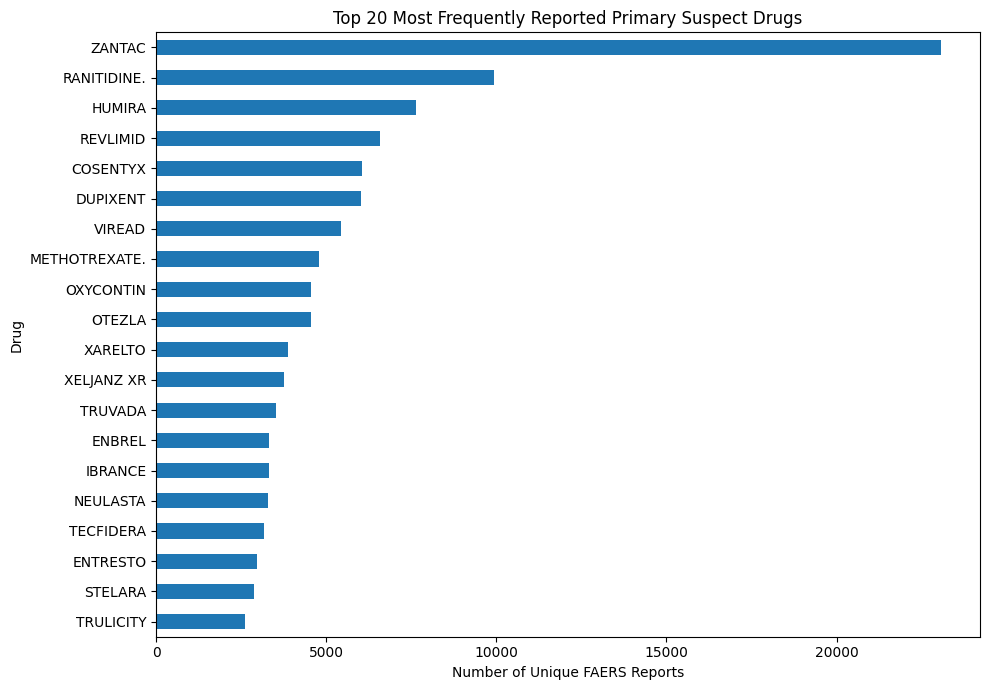

In [19]:
# Create horizontal bar chart
plt.figure(figsize=(10, 7))

top_drugs.sort_values().plot(
    kind="barh"
)

plt.title("Top 20 Most Frequently Reported Primary Suspect Drugs")
plt.xlabel("Number of Unique FAERS Reports")
plt.ylabel("Drug")

plt.tight_layout()

# Save the figure
plt.savefig(
    "figures/top_20_drugs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# Count unique reports for each adverse reaction
top_reactions = (merged_ps.groupby("pt")["primaryid"].nunique().sort_values(ascending=False).head(20))

print("Top 20 reactions:")
print(top_reactions)

Top 20 reactions:
pt
Drug ineffective                        28554
Off label use                           20147
Pain                                    17983
Fatigue                                 17622
Death                                   17378
Nausea                                  16142
Diarrhoea                               14972
Headache                                13557
Dyspnoea                                12997
Treatment failure                       12854
Product dose omission issue             12425
Arthralgia                              10339
Dizziness                                9550
Vomiting                                 9457
Product use in unapproved indication     9137
Anxiety                                  8946
Rash                                     8621
Malaise                                  8081
Pyrexia                                  8054
Condition aggravated                     8051
Name: primaryid, dtype: int64


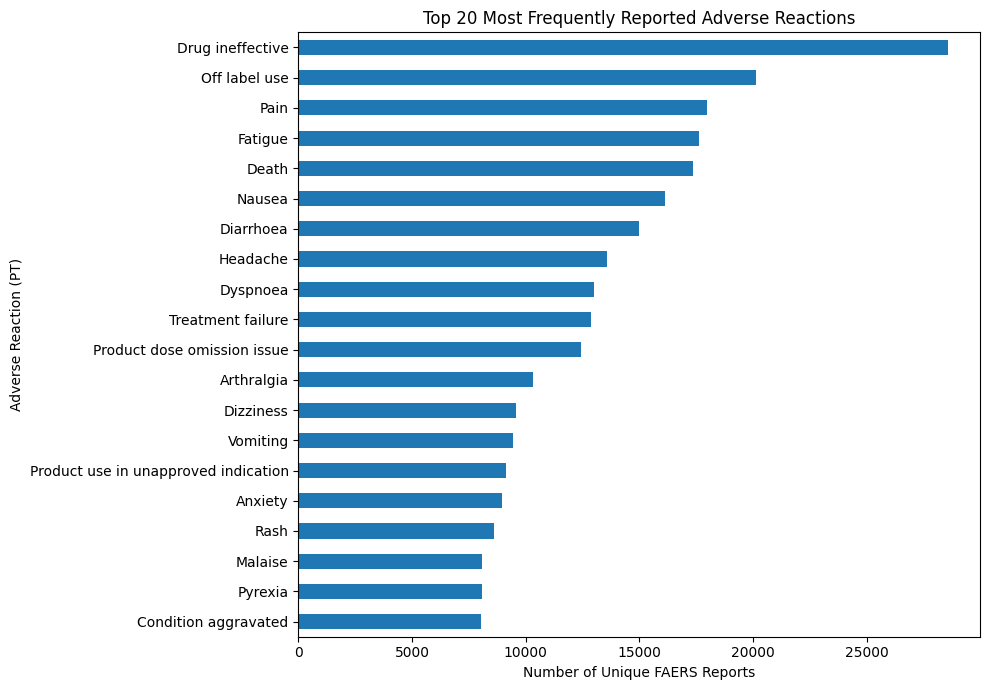

In [21]:
# Create horizontal bar chart
plt.figure(figsize=(10, 7))

top_reactions.sort_values().plot(
    kind="barh"
)

plt.title("Top 20 Most Frequently Reported Adverse Reactions")
plt.xlabel("Number of Unique FAERS Reports")
plt.ylabel("Adverse Reaction (PT)")

plt.tight_layout()

# Save the figure
plt.savefig(
    "figures/top_20_reactions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
# Make a copy so we don't modify the original DEMO dataframe
demo_age_sex = demo.copy()

# Convert age to numeric
# Invalid/missing values become NaN
demo_age_sex["age"] = pd.to_numeric(
    demo_age_sex["age"],
    errors="coerce"
)

# Keep ages between 0 and 100, Also keep only M and F because these are the standard

age_sex = demo_age_sex[demo_age_sex["age"].between(0, 100) & demo_age_sex["sex"].isin(["M", "F"])].copy()

print("Valid age/sex records:", len(age_sex))
print("\nSex distribution:")
print(age_sex["sex"].value_counts())

Valid age/sex records: 211910

Sex distribution:
sex
F    123987
M     87923
Name: count, dtype: int64


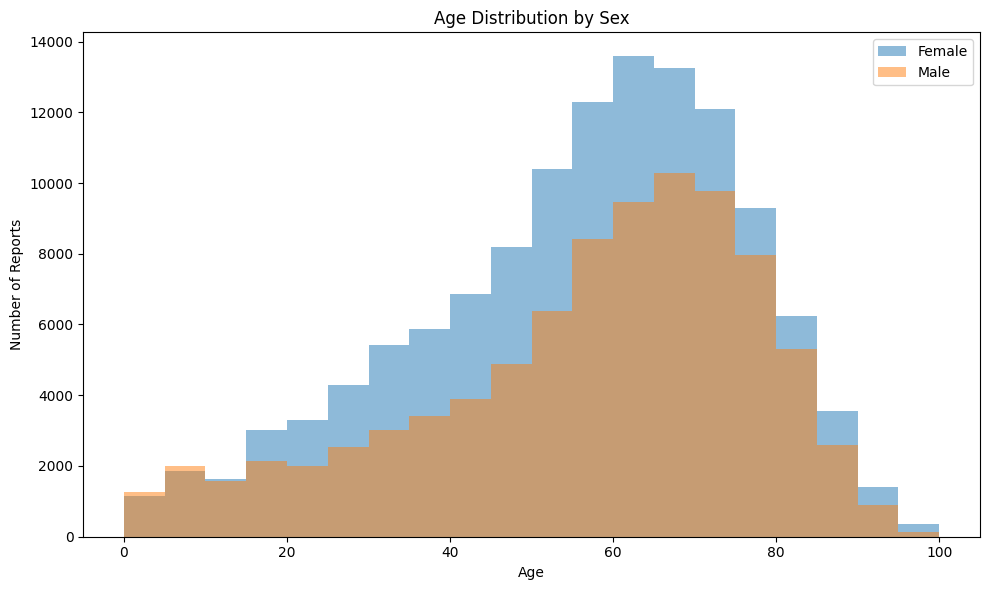

In [23]:
# Plot age distribution separately for males and females

plt.figure(figsize=(10, 6))

age_sex[age_sex["sex"] == "F"]["age"].plot(
    kind="hist",
    bins=20,
    alpha=0.5,
    label="Female"
)

age_sex[age_sex["sex"] == "M"]["age"].plot(
    kind="hist",
    bins=20,
    alpha=0.5,
    label="Male"
)

plt.title("Age Distribution by Sex")
plt.xlabel("Age")
plt.ylabel("Number of Reports")
plt.legend()

plt.tight_layout()

# Save figure
plt.savefig(
    "figures/age_sex_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
# Create results folder
os.makedirs("results", exist_ok=True)

In [25]:
# use PRIMARYID to count reports only once.

N = demo["primaryid"].nunique()

print("Total unique FAERS reports:", N)


Total unique FAERS reports: 431667


In [26]:
# Count unique reports for each drug-ADR pair and store the counts in a new DataFrame called pair_counts. The count is stored in a column named "a".
pair_counts = (merged.groupby(["drugname", "pt"])["primaryid"].nunique().reset_index(name="a"))

# Keep only pairs with a >= 3
pair_counts = pair_counts[pair_counts["a"] >= 3].copy()



In [27]:
# Total UNIQUE reports for each drug using PRIMARYID to count reports only once. The counts are stored in a dictionary called drug_totals, where the keys are drug names and the values are the corresponding unique report counts.

drug_totals = (merged.groupby("drugname")["primaryid"].nunique().to_dict())


# Total UNIQUE reports for each ADR and store the counts in a dictionary called adr_totals, where the keys are ADR names and the values are the corresponding unique report counts.
adr_totals = (merged.groupby("pt")["primaryid"].nunique().to_dict())

The formulas to Calculate a, b, c, d

a = Drug X + ADR Y

b = Drug X + other ADRs
  = reports with Drug X - a

c = Other drugs + ADR Y
  = reports with ADR Y - a

d = everything else
  = N - a - b - c

In [28]:
# Calculate the total unique reports for each drug and ADR
pair_counts["drug_total"] = (pair_counts["drugname"].map(drug_totals))

# Calculate the total unique reports for each ADR
pair_counts["adr_total"] = (pair_counts["pt"].map(adr_totals))


# b = all reports with drug X - reports with drug X + ADR Y

pair_counts["b"] = (pair_counts["drug_total"]- pair_counts["a"])


# c = all reports with ADR Y - reports with drug X + ADR Y

pair_counts["c"] = (pair_counts["adr_total"]- pair_counts["a"])


# d = everything else

pair_counts["d"] = (N- pair_counts["a"]- pair_counts["b"]- pair_counts["c"])



#Check that every contingency table sums to N

check_total = (pair_counts["a"]+ pair_counts["b"]+ pair_counts["c"]+ pair_counts["d"])

print(
    "All contingency tables sum to N:",(check_total == N).all())

All contingency tables sum to N: True


In [29]:

# 7. Calculate PRR, ROR, CI, Chi-square and Fisher

results = []


for _, row in pair_counts.iterrows():

    drug = row["drugname"]
    adr = row["pt"]

    a = int(row["a"])
    b = int(row["b"])
    c = int(row["c"])
    d = int(row["d"])


   
    # PRR
    
    # PRR = [a/(a+b)] / [c/(c+d)]
    
    # here we check that the denominators are not zero to avoid division by zero errors. 
    if (a + b) > 0 and (c + d) > 0:
        # here we check that the numerator of the second fraction is not zero to avoid division by zero errors.
        if c > 0:
            prr = (
                (a / (a + b))
                /
                (c / (c + d))
            )
        else:
            # Zero denominator -> mathematically infinite
            prr = np.inf

    else:
        prr = np.nan


   
    # ROR
    
    # ROR = (a*d)/(b*c)
    
    # Cannot calculate standard ROR if b or c = 0.
    
    # to avoid division by zero errors, we check that b and c are greater than 0 before calculating ROR.
    if b > 0 and c > 0 and d > 0:

        ror = (a * d) / (b * c)


        # Standard error of log(ROR)

        se = np.sqrt(
            1/a +
            1/b +
            1/c +
            1/d
        )


        # 95% CI
        # using the formula: CI = exp(log(ROR) ± 1.96 * SE)
        ci_lower = np.exp(
            np.log(ror) - 1.96 * se
        )
        # using the formula: CI = exp(log(ROR) ± 1.96 * SE)
        ci_upper = np.exp(
            np.log(ror) + 1.96 * se
        )

    else:

        ror = np.nan
        ci_lower = np.nan
        ci_upper = np.nan


    
    # Chi-square
    

    table = [
        [a, b],
        [c, d]
    ]
    # check that the table is valid for chi-square test
    chi2_value, chi2_p, _, expected = chi2_contingency(
        table,
        correction=False
    )


    
    # Fisher's exact test
    
    # Assignment asks for Fisher's exact p-value for
    # small counts.
    
    # Here we use it when the minimum expected cell count
    # is < 5.
    
    # for small counts, we use Fisher's exact test to calculate the p-value. We initialize fisher_p to NaN and only calculate it if the minimum expected cell count is less than 5.
    fisher_p = np.nan

    if expected.min() < 5:

        _, fisher_p = fisher_exact(
            table,
            alternative="two-sided"
        )


   
    # Signal criteria
    
    # a >= 3
    # PRR >= 2
    # Chi2 >= 4
  
     
    is_signal = (
        (a >= 3)
        and (prr >= 2)
        and (chi2_value >= 4)
    )


    
    # Store results
   
    # append the results for this drug-ADR pair to the results list. Each entry in the list is a dictionary containing the drug name, ADR, contingency table counts, PRR, ROR, confidence intervals, chi-square value and p-value, Fisher's exact test p-value, and whether the pair meets the signal criteria.
    results.append({
        "Drug": drug,
        "ADR": adr,

        "a": a,
        "b": b,
        "c": c,
        "d": d,

        "PRR": prr,

        "ROR": ror,

        "ROR_CI_Lower": ci_lower,
        "ROR_CI_Upper": ci_upper,

        "Chi2": chi2_value,
        "Chi2_p": chi2_p,

        "Fisher_p": fisher_p,

        "Signal": is_signal
    })


A drug–ADR pair was flagged as a potential signal when it had at least 3 reports (a ≥ 3), a proportional reporting ratio of at least 2 (PRR ≥ 2), and a Pearson chi-square statistic of at least 4 (Chi² ≥ 4). These standard thresholds identify drug–ADR combinations with sufficient minimum reporting frequency and evidence of disproportional reporting. A flagged pair represents a potential safety signal and does not establish causality.

In [30]:

# Create final DataFrame

signals_df = pd.DataFrame(results)


In [31]:

# Save CSV
# make results folder if it does not already exist
os.makedirs("results", exist_ok=True)
# save the signals DataFrame to a CSV file
signals_df.to_csv(
    "results/FAERS_signals.csv",
    index=False
)



# 11. Summary


print(f"Total drug–ADR pairs evaluated: {len(signals_df):,}")

print(f"Total potential signals: " f"{signals_df['Signal'].sum():,}")




print("\nTOP 10 RESULTS")

signals_df.head(10)


Total drug–ADR pairs evaluated: 484,773
Total potential signals: 325,860

TOP 10 RESULTS


,Drug,ADR,a,b,c,d,PRR,ROR,ROR_CI_Lower,ROR_CI_Upper,Chi2,Chi2_p,Fisher_p,Signal
0,0.9% SODIUM CHLORIDE INJECTION,Agranulocytosis,16,73,328,431250,236.545903,288.172402,165.967649,500.358558,3581.106976,0.000000e+00,3.111155e-33,True
1,0.9% SODIUM CHLORIDE INJECTION,Chest discomfort,3,86,2255,429323,6.451252,6.641412,2.098885,21.015133,13.872990,1.955893e-04,1.162617e-02,True
2,0.9% SODIUM CHLORIDE INJECTION,Chest pain,3,86,3426,428152,4.246227,4.359467,1.378071,13.790988,7.498239,6.175934e-03,3.434396e-02,True
3,0.9% SODIUM CHLORIDE INJECTION,Dyspnoea,3,86,12994,418584,1.119561,1.123732,0.355350,3.553603,0.039485,8.424917e-01,7.515966e-01,False
4,0.9% SODIUM CHLORIDE INJECTION,Leukopenia,36,53,1199,430379,145.597061,243.813933,159.065166,373.716227,5033.445240,0.000000e+00,1.463953e-67,True
5,0.9% SODIUM CHLORIDE INJECTION,Myelosuppression,36,53,794,430784,219.862565,368.523929,239.967922,565.950171,7517.482838,0.000000e+00,7.288483e-74,True
6,0.9% SODIUM CHLORIDE INJECTION,Nausea,4,85,16138,415440,1.201931,1.211434,0.444363,3.302638,0.140939,7.073494e-01,5.771714e-01,False
7,0.9% SODIUM CHLORIDE INJECTION,Neutropenia,5,84,3041,428537,7.973020,8.388081,3.400281,20.692381,30.658502,3.076755e-08,4.429537e-04,True
8,0.9% SODIUM CHLORIDE INJECTION,Neutrophil count decreased,6,83,944,430634,30.821129,32.976874,14.364579,75.705263,172.407478,2.204806e-39,5.563156e-08,True
9,0.9% SODIUM CHLORIDE INJECTION,Pancytopenia,4,85,1162,430416,16.692568,17.431042,6.384080,47.593580,58.966743,1.603595e-14,1.077363e-04,True


Interpretation of Top Candidate Signals

Three candidate signals were selected based on their high PRR values: 3TC–blood bilirubin increased, 3TC/ LAMIVUDINE –cholelithiasis, and 3TC–blood lactic acid increased. These findings represent disproportional reporting within FAERS and should be interpreted as signals for further investigation rather than evidence of causality.

lamivudine – Blood bilirubin increased

The association between 3TC (lamivudine) and increased blood bilirubin warrants further evaluation because bilirubin abnormalities can occur in the hepatic adverse effects. Lamivudine prescribing information reports hepatic adverse events and laboratory abnormalities, although the FAERS signal itself cannot determine whether lamivudine caused the observed bilirubin increase.

Risk management: Continued monitoring of liver function and bilirubin may be appropriate when clinically indicated, particularly in patients with underlying hepatic disease or concomitant hepatotoxic medications.

3TC – Cholelithiasis

The cholelithiasis signal showed a very high PRR in this dataset. This finding requires particular caution because a high FAERS disproportionality measure can be influenced by co-medications, underlying disease, reporting patterns, and small or unevenly distributed comparison groups. An FDA analysis of FAERS has previously examined bile-duct/gallbladder events and reported elevated disproportionality measures for some antiretroviral nucleoside reverse-transcriptase inhibitors, including lamivudine, while also noting that other medications may contribute to the observed associations.

Risk management: The signal should be followed through case-level review, assessment of concomitant medications and indications, and comparison with other antiretroviral agents before drawing clinical conclusions.

3TC – Blood lactic acid increased

This signal has the clearest biological plausibility of the three. Lamivudine is a nucleoside analogue, and its prescribing information specifically warns about lactic acidosis and severe hepatomegaly with steatosis associated with nucleoside analogues, including lamivudine.

Risk management: Patients who develop clinical or laboratory findings suggestive of lactic acidosis or pronounced hepatotoxicity require clinical evaluation, and the prescribing information recommends suspending treatment when such findings occur.

Surveillance and Reporting Bias

These signals should not be interpreted as estimates of incidence or individual patient risk. FAERS is a spontaneous reporting system and lacks a reliable denominator of exposed patients. Reporting can also be influenced by stimulated reporting, regulatory attention, media coverage, indication-related confounding, co-medications, and differences in reporting practices. Therefore, the extremely high PRRs observed for these pairs may partly reflect characteristics of the reporting system rather than a direct pharmacological effect.

A useful next step would be to perform case-level review and stratified analyses, particularly by indication, age, sex, concomitant medications, and reporting year. Rare-event signals should also be evaluated using a shrinkage method such as empirical Bayes/EBGM, which can reduce instability from small cell counts.

Overall interpretation: The three pairs should be treated as candidate pharmacovigilance signals requiring validation, not as confirmed adverse drug reactions. The 3TC–blood lactic acid increased association has particularly clear support from existing prescribing information, whereas the bilirubin and cholelithiasis findings require additional investigation to separate a potential drug effect from confounding and reporting bias.

Top drug: ZANTAC
Top ADR: Drug ineffective


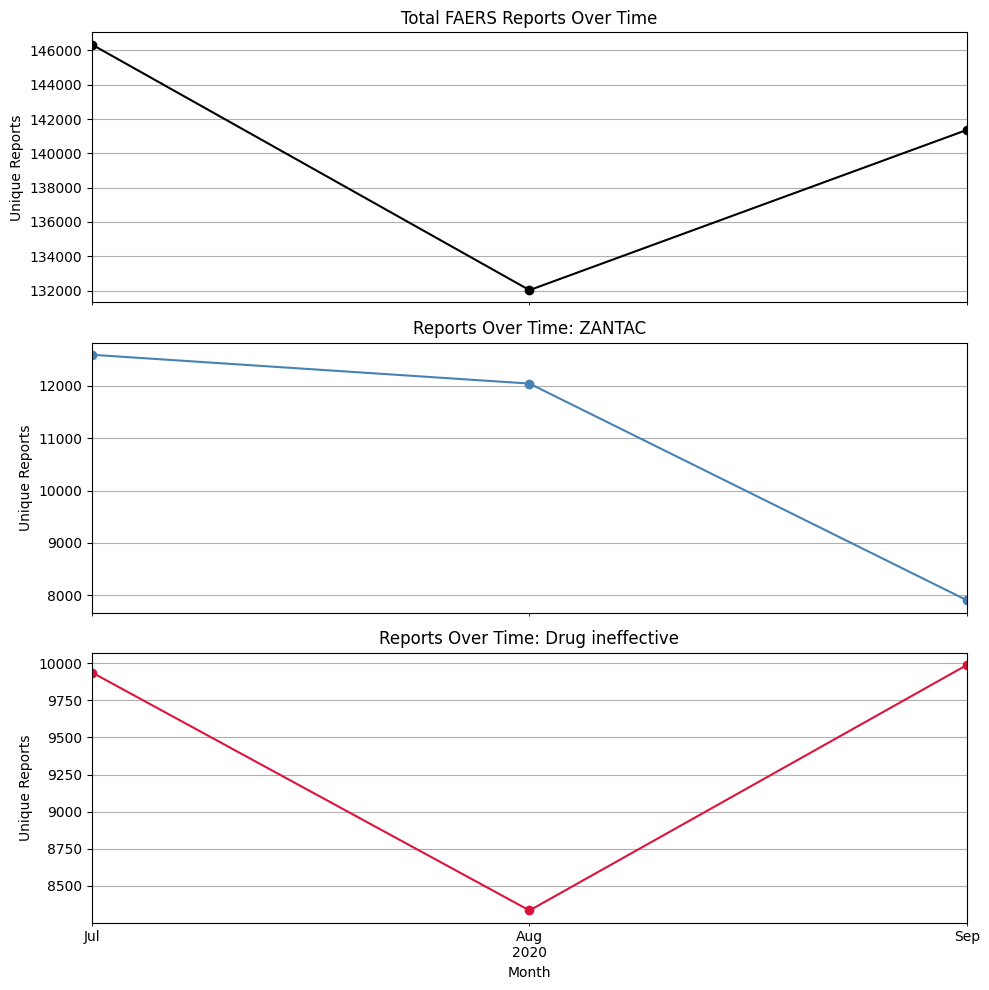

In [36]:


# Convert FDA_DT to datetime
# FDA_DT format = YYYYMMDD
merged['fda_dt_clean'] = pd.to_datetime(
    merged['fda_dt'],
    format='%Y%m%d',
    errors='coerce'
)

df_time = df_time[
    (df_time['fda_dt_clean'] >= '2020-07-01') &
    (df_time['fda_dt_clean'] <= '2020-09-30')
].copy()

df_time['month'] = df_time['fda_dt_clean'].dt.to_period('M')
# Remove missing/invalid dates
df_time = df_time.dropna(subset=['fda_dt_clean']).copy()

# Create Year-Month column
df_time['month'] = df_time['fda_dt_clean'].dt.to_period('M')

# Find top drug and top ADR

# Top drug based on number of UNIQUE FAERS reports
top_drug = (
    df_time.groupby('drugname')['primaryid']
    .nunique()
    .sort_values(ascending=False)
    .index[0]
)

# Top ADR based on number of UNIQUE FAERS reports
top_adr = (
    df_time.groupby('pt')['primaryid']
    .nunique()
    .sort_values(ascending=False)
    .index[0]
)

print("Top drug:", top_drug)
print("Top ADR:", top_adr)



# Count unique reports per month


# Total reports per month
total_per_month = (
    df_time
    .groupby('month')['primaryid']
    .nunique()
)

# Reports involving the top drug
drug_per_month = (
    df_time[df_time['drugname'] == top_drug]
    .groupby('month')['primaryid']
    .nunique()
)

# Reports involving the top ADR
adr_per_month = (
    df_time[df_time['pt'] == top_adr]
    .groupby('month')['primaryid']
    .nunique()
)


# 4. Plot all three trends


fig, axes = plt.subplots(
    3, 1,
    figsize=(10, 10),
    sharex=True
)


# Total reports
total_per_month.plot(
    ax=axes[0],
    color='black',
    marker='o'
)

axes[0].set_title("Total FAERS Reports Over Time")
axes[0].set_ylabel("Unique Reports")
axes[0].grid(True)


# Top drug
drug_per_month.plot(
    ax=axes[1],
    color='steelblue',
    marker='o'
)

axes[1].set_title(f"Reports Over Time: {top_drug}")
axes[1].set_ylabel("Unique Reports")
axes[1].grid(True)


# Top ADR
adr_per_month.plot(
    ax=axes[2],
    color='crimson',
    marker='o'
)

axes[2].set_title(f"Reports Over Time: {top_adr}")
axes[2].set_ylabel("Unique Reports")
axes[2].grid(True)


plt.xlabel("Month")
plt.tight_layout()

# Save figure
plt.savefig(
    "figures/time_series_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
# Count unique reports per quarter
quarterly_reports = (
    df_time
    .groupby(df_time['fda_dt_clean'].dt.to_period('Q'))['primaryid']
    .nunique()
)

print("Total reports per quarter:")
print(quarterly_reports)

Total reports per quarter:
fda_dt_clean
2020Q3    419732
Freq: Q-DEC, Name: primaryid, dtype: int64


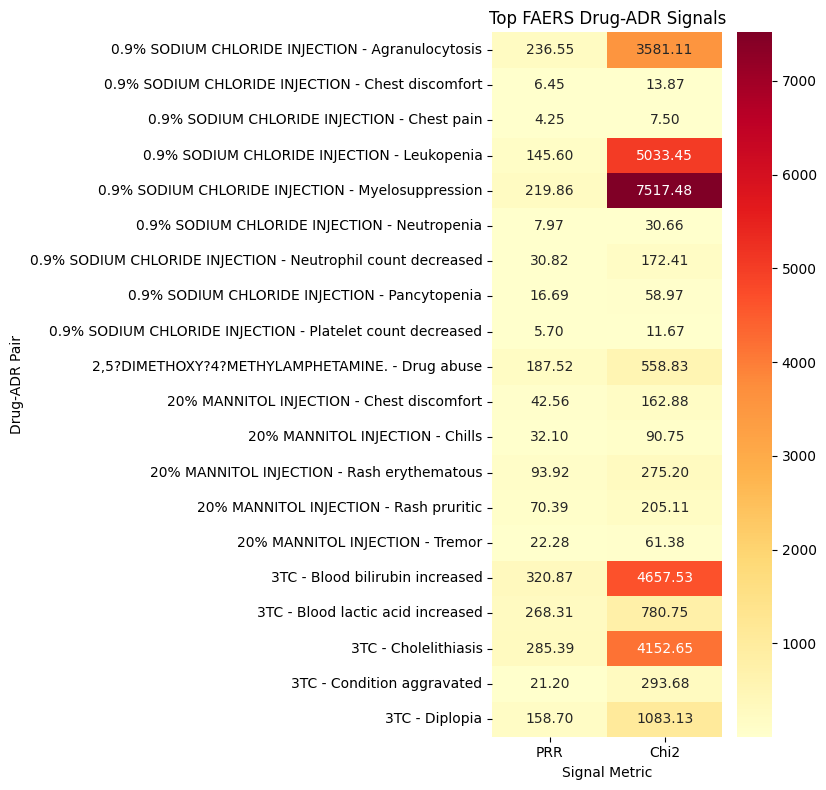

In [ ]:
# heatmap of top signals
# Load signal results
df = pd.read_csv("results/FAERS_signals.csv")

# Keep only signals
df = df[df["Signal"] == True].head(20)

# Create drug-ADR labels
df["Pair"] = df["Drug"] + " - " + df["ADR"]

# Heatmap using PRR and Chi-square
data = df.set_index("Pair")[["PRR", "Chi2"]]

plt.figure(figsize=(8, 8))
sns.heatmap(data, annot=True, fmt=".2f", cmap="YlOrRd")

plt.title("Top FAERS Drug-ADR Signals")
plt.xlabel("Signal Metric")
plt.ylabel("Drug-ADR Pair")

plt.tight_layout()
plt.savefig("figures/signal_heatmap.png", dpi=300)
plt.show()

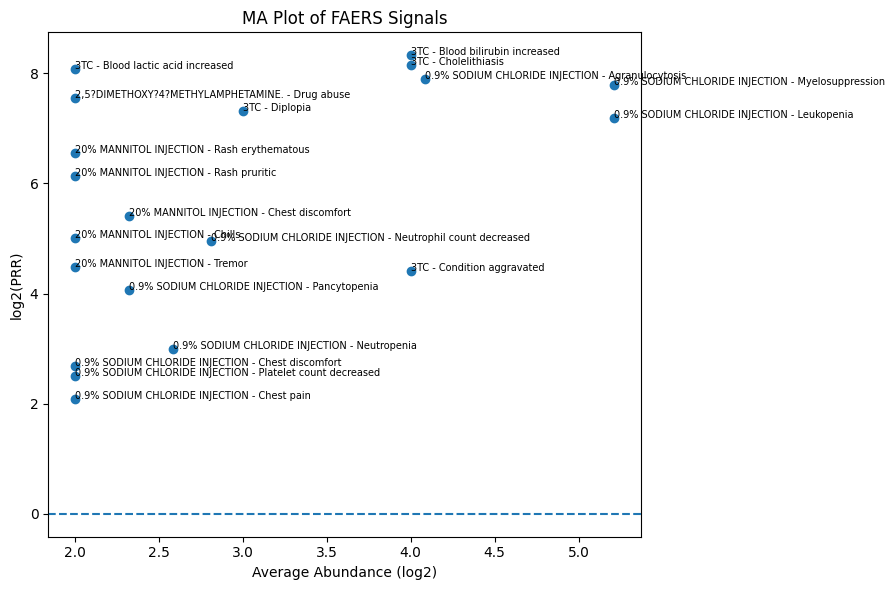

In [ ]:

# MA Plot with log2(PRR) vs log2(Average Abundance)
ma = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["PRR"])

A = np.log2(ma["a"] + 1)
M = np.log2(ma["PRR"])

plt.figure(figsize=(9, 6))
plt.scatter(A, M)

for i, row in ma.iterrows():
    plt.annotate(
        row["Drug"] + " - " + row["ADR"],
        (A.loc[i], M.loc[i]),
        fontsize=7
    )

plt.axhline(0, linestyle="--")
plt.xlabel("Average Abundance (log2)")
plt.ylabel("log2(PRR)")
plt.title("MA Plot of FAERS Signals")

plt.tight_layout()
plt.savefig("figures/MA_plot.png", dpi=300)
plt.show()